In [2]:
import numpy as np
import pandas as pd

In [3]:
rd = pd.read_csv("R&D.csv")

print(rd.head())
print(rd.columns)

  STRUCTURE                                 STRUCTURE_ID  \
0  DATAFLOW  OECD.STI.STP:DSD_RDS_GERD@DF_GERD_FORD(1.0)   
1  DATAFLOW  OECD.STI.STP:DSD_RDS_GERD@DF_GERD_FORD(1.0)   
2  DATAFLOW  OECD.STI.STP:DSD_RDS_GERD@DF_GERD_FORD(1.0)   
3  DATAFLOW  OECD.STI.STP:DSD_RDS_GERD@DF_GERD_FORD(1.0)   
4  DATAFLOW  OECD.STI.STP:DSD_RDS_GERD@DF_GERD_FORD(1.0)   

                                      STRUCTURE_NAME ACTION REF_AREA  \
0  Gross domestic expenditure on R&D by sector of...      I      AUT   
1  Gross domestic expenditure on R&D by sector of...      I      AUT   
2  Gross domestic expenditure on R&D by sector of...      I      AUT   
3  Gross domestic expenditure on R&D by sector of...      I      AUT   
4  Gross domestic expenditure on R&D by sector of...      I      AUT   

  Reference area FREQ Frequency of observation MEASURE  \
0        Austria    A                   Annual       G   
1        Austria    A                   Annual       G   
2        Austria    A           

/var/folders/nk/d0gbqgzj30d21jjn_bxj9dmc0000gn/T/ipykernel_3898/3160315949.py:1: DtypeWarning: Columns (34,35,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  rd = pd.read_csv("R&D.csv")


In [6]:
rd = rd[[
    "REF_AREA",
    "Reference area",
    "TIME_PERIOD",
    "OBS_VALUE"
]]


In [7]:
rd = rd.rename(columns={
    "REF_AREA": "countrycode",
    "Reference area": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "rd"
})

In [8]:
rd_2000 = rd[rd["year"] == 2000]

In [9]:
rd_2000 = rd_2000.dropna(subset=["rd"])

In [10]:
rd_2000["countrycode"].value_counts().head()

countrycode
POL    150
ARG    150
ESP    150
RUS    150
BGR    150
Name: count, dtype: int64

In [11]:
rd.columns

Index(['countrycode', 'country', 'year', 'rd'], dtype='object')

In [26]:
rd_clean = rd.groupby(["countrycode", "year"])["rd"].mean().reset_index()

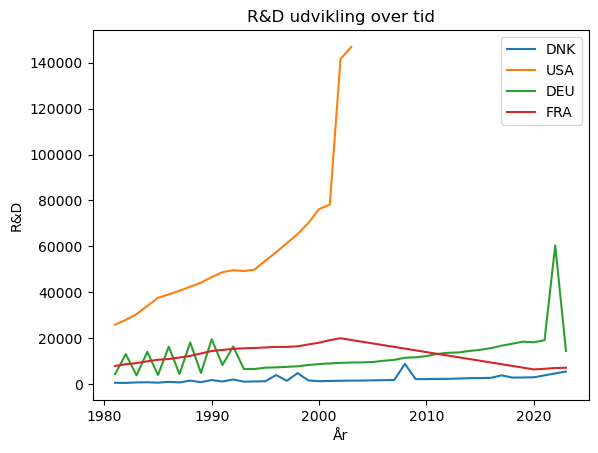

In [27]:
countries = ["DNK", "USA", "DEU", "FRA"]

for c in countries:
    temp = rd_clean[rd_clean["countrycode"] == c].sort_values("year")
    plt.plot(temp["year"], temp["rd"], label=c)

plt.legend()
plt.title("R&D udvikling over tid")
plt.xlabel("År")
plt.ylabel("R&D")
plt.show()

In [28]:
rd.describe()

,year,rd
count,108013.000000,1.080130e+05
mean,2007.048587,9.772070e+04
std,10.453773,1.979883e+06
min,1981.000000,0.000000e+00
25%,2000.000000,2.644120e+01
50%,2008.000000,2.028546e+02
75%,2016.000000,1.433556e+03
max,2024.000000,1.190740e+08
